In [1]:
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

In [2]:
isin = pd.read_excel('Data\\EA_ISINs.xlsx')

In [3]:
unique_isin = tuple(isin['ISIN'])

In [4]:
treasury = pd.read_csv('Data\\TreasuryCUSIP.csv')

In [5]:
unique_treasury = tuple(treasury['ISIN'].unique())

# Do Funds trade both EUR and USD?

In [8]:
# Data prep
query = f"""

SELECT DISTINCT borrower_id as entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}

"""

df_borrowing_eur = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_35380\802568247.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing_eur = pd.read_sql_query(query, cnxn)


In [9]:
# Data prep
query = f"""

SELECT DISTINCT lender_id as entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}

"""

df_lending_eur = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_35380\2658806809.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending_eur = pd.read_sql_query(query, cnxn)


In [10]:
# Data prep
query = f"""

SELECT DISTINCT borrower_id as entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}

"""

df_borrowing_usd = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_35380\4248610493.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing_usd = pd.read_sql_query(query, cnxn)


In [11]:
# Data prep
query = f"""

SELECT DISTINCT lender_id as entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}

"""

df_lending_usd = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_35380\1078993250.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending_usd = pd.read_sql_query(query, cnxn)


In [12]:
# After pulling EUR and USD data
eur_entities = set(df_borrowing_eur['entity_id'].unique()) | set(df_lending_eur['entity_id'].unique())
usd_entities = set(df_borrowing_usd['entity_id'].unique()) | set(df_lending_usd['entity_id'].unique())

both = eur_entities & usd_entities
eur_only = eur_entities - usd_entities
usd_only = usd_entities - eur_entities

print(f"EUR only: {len(eur_only)}")
print(f"USD only: {len(usd_only)}")
print(f"Both:     {len(both)}")
print(f"Total:    {len(eur_entities | usd_entities)}")

EUR only: 53
USD only: 121
Both:     145
Total:    319


## how about volumes

In [6]:
# Data prep
query = f"""

SELECT borrower_id as entity_id, SUM(nominal_value) as volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY entity_id

"""

df_borrowing_eur = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_56124\806378064.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing_eur = pd.read_sql_query(query, cnxn)


In [7]:
# Data prep
query = f"""

SELECT lender_id as entity_id, SUM(nominal_value) as volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY entity_id

"""

df_lending_eur = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_56124\3055425638.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending_eur = pd.read_sql_query(query, cnxn)


In [8]:
# Data prep
query = f"""

SELECT borrower_id as entity_id, SUM(nominal_value) as volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY entity_id

"""

df_borrowing_usd = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_56124\3814541093.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing_usd = pd.read_sql_query(query, cnxn)


In [9]:
# Data prep
query = f"""

SELECT lender_id as entity_id, SUM(nominal_value) as volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY entity_id

"""

df_lending_usd = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_56124\17673085.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending_usd = pd.read_sql_query(query, cnxn)


In [10]:
# Combine borrowing + lending volumes per entity per currency
eur_entities = set(df_borrowing_eur['entity_id'].unique()) | set(df_lending_eur['entity_id'].unique())
usd_entities = set(df_borrowing_usd['entity_id'].unique()) | set(df_lending_usd['entity_id'].unique())

both = eur_entities & usd_entities

eur_vol = pd.concat([df_borrowing_eur, df_lending_eur]).groupby('entity_id')['volume'].sum().reset_index()
usd_vol = pd.concat([df_borrowing_usd, df_lending_usd]).groupby('entity_id')['volume'].sum().reset_index()

# Tag each entity
eur_vol['category'] = eur_vol['entity_id'].apply(lambda x: 'Both' if x in both else 'EUR only')
usd_vol['category'] = usd_vol['entity_id'].apply(lambda x: 'Both' if x in both else 'USD only')

# Volume shares
eur_shares = eur_vol.groupby('category')['volume'].sum()
print("EUR volume shares:")
print(eur_shares / eur_shares.sum())

usd_shares = usd_vol.groupby('category')['volume'].sum()
print("\nUSD volume shares:")
print(usd_shares / usd_shares.sum())

EUR volume shares:
category
Both        0.992801
EUR only    0.007199
Name: volume, dtype: float64

USD volume shares:
category
Both        0.983371
USD only    0.016629
Name: volume, dtype: float64


In [ ]:
eur_vol_all = eur_vol.sort_values('volume', ascending=False)
eur_vol_all['cumshare'] = eur_vol_all['volume'].cumsum() / eur_vol_all['volume'].sum()
print(eur_vol_all[['entity_id', 'cumshare']].head(20))

                entity_id  cumshare
160  FJV0KIIMRXLMWV5QT846  0.150468
173  O1XNTICYRCAHEAMEQI31  0.270611
174  P5XEQYFJP74DYQX88M80  0.335355
19   2CNR4I7RPCUNYMQ52H12  0.399981
52   5493008P9DJX0WNGA303  0.459777
62   549300CSOBZVGIW07Z43  0.506547
58   549300APE0JGFJ9JMB36  0.547496
106  549300RXYC2IDG39CW23  0.583992
79   549300HY72WJJ6KYOB71  0.619295
161  FUKBWKZPQPD7DNK1WY51  0.653409
88   549300KM4DRKLEPZUO76  0.685893
72   549300FV62LGN1DBJF68  0.711151
23   3KXPVCIB6BML2IWOMX37  0.735690
100  549300OR6B15UIZ9FZ95  0.754757
157  DS1LD4KRZVNKQC3WP076  0.770916
36   5493002SCIQPX6PFKZ81  0.786860
94   549300NFUQNQSETLCP08  0.802087
31   5493001KV0UXB1QVXK48  0.816134
155  DBMPQSXT0LEURZ0IGP72  0.829507
196  ZMMTKV5LOQGJW1P6GK81  0.842099


In [21]:
usd_vol_all = usd_vol.sort_values('volume', ascending=False)
usd_vol_all['cumshare'] = usd_vol_all['volume'].cumsum() / usd_vol_all['volume'].sum()
print(usd_vol_all[['entity_id', 'cumshare']].head(20))

                entity_id  cumshare
228  O1XNTICYRCAHEAMEQI31  0.102602
232  P5XEQYFJP74DYQX88M80  0.191205
211  FJV0KIIMRXLMWV5QT846  0.274546
126  549300KM4DRKLEPZUO76  0.339558
155  549300RXYC2IDG39CW23  0.400181
212  FUKBWKZPQPD7DNK1WY51  0.442204
74   5493008P9DJX0WNGA303  0.480209
207  DBMPQSXT0LEURZ0IGP72  0.515437
25   2CNR4I7RPCUNYMQ52H12  0.544739
87   549300CSOBZVGIW07Z43  0.571855
79   549300APE0JGFJ9JMB36  0.597418
260  YKS4QSSUSHKAP291P823  0.622718
135  549300NFUQNQSETLCP08  0.647251
234  PLH0I0VQA1SU41NKTM31  0.668217
102  549300FV62LGN1DBJF68  0.688432
253  WHLAIMQOU4GJKYFZHC97  0.708469
170  549300VDTX66AKKIYG35  0.727317
63   5493006RTMUWN17BI189  0.745902
186  549300ZWDQ7M5QBY0093  0.764400
17   22KMWLRMY0MUEN0W5D90  0.781868


# Counterparties of Hedge funds

In [6]:
# Data prep
query = f"""

SELECT DISTINCT lender_id as entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}

"""

df_cp_eur_1 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\777786766.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cp_eur_1 = pd.read_sql_query(query, cnxn)


In [7]:
# Data prep
query = f"""

SELECT DISTINCT borrower_id as entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}

"""

df_cp_eur_2 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\2634727267.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cp_eur_2 = pd.read_sql_query(query, cnxn)


In [8]:
# Data prep
query = f"""

SELECT DISTINCT lender_id as entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}

"""

df_cp_usd_1 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\949573789.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cp_usd_1 = pd.read_sql_query(query, cnxn)


In [9]:
# Data prep
query = f"""

SELECT DISTINCT borrower_id as entity_id
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}

"""

df_cp_usd_2 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\2748296159.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cp_usd_2 = pd.read_sql_query(query, cnxn)


In [11]:
eur_cp = set(df_cp_eur_1['entity_id']) | set(df_cp_eur_2['entity_id'])
usd_cp = set(df_cp_usd_1['entity_id']) | set(df_cp_usd_2['entity_id'])

both_cp = eur_cp & usd_cp
eur_only_cp = eur_cp - usd_cp
usd_only_cp = usd_cp - eur_cp

print(f"EUR only: {len(eur_only_cp)}")
print(f"USD only: {len(usd_only_cp)}")
print(f"Both:     {len(both_cp)}")
print(f"Total:    {len(eur_cp | usd_cp)}")

EUR only: 23
USD only: 19
Both:     20
Total:    62


## How about volumes

In [12]:
# Data prep
query = f"""

SELECT lender_id as entity_id, SUM(nominal_value) as volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY entity_id

"""

df_cp_eur_vol_1 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\1203144623.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cp_eur_vol_1 = pd.read_sql_query(query, cnxn)


In [13]:
# Data prep
query = f"""

SELECT borrower_id as entity_id, SUM(nominal_value) as volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY entity_id

"""

df_cp_eur_vol_2 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\511413471.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cp_eur_vol_2 = pd.read_sql_query(query, cnxn)


In [14]:
# Data prep
query = f"""

SELECT lender_id as entity_id, SUM(nominal_value) as volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY entity_id

"""

df_cp_usd_vol_1 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\3783261874.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cp_usd_vol_1 = pd.read_sql_query(query, cnxn)


In [15]:
# Data prep
query = f"""

SELECT borrower_id as entity_id, SUM(nominal_value) as volume
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY entity_id

"""

df_cp_usd_vol_2 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\2912360833.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cp_usd_vol_2 = pd.read_sql_query(query, cnxn)


In [ ]:
eur_cp = set(df_cp_eur_1['entity_id']) | set(df_cp_eur_2['entity_id'])
usd_cp = set(df_cp_usd_1['entity_id']) | set(df_cp_usd_2['entity_id'])

both_cp = eur_cp & usd_cp
eur_only_cp = eur_cp - usd_cp
usd_only_cp = usd_cp - eur_cp

In [17]:
eur_cp_vol = pd.concat([df_cp_eur_vol_1, df_cp_eur_vol_2]).groupby('entity_id')['volume'].sum().reset_index()
usd_cp_vol = pd.concat([df_cp_usd_vol_1, df_cp_usd_vol_2]).groupby('entity_id')['volume'].sum().reset_index()

eur_cp_vol['category'] = eur_cp_vol['entity_id'].apply(lambda x: 'Both' if x in both_cp else 'EUR only')
usd_cp_vol['category'] = usd_cp_vol['entity_id'].apply(lambda x: 'Both' if x in both_cp else 'USD only')

eur_shares = eur_cp_vol.groupby('category')['volume'].sum()
print("EUR counterparty volume shares:")
print(eur_shares / eur_shares.sum())

usd_shares = usd_cp_vol.groupby('category')['volume'].sum()
print("\nUSD counterparty volume shares:")
print(usd_shares / usd_shares.sum())

EUR counterparty volume shares:
category
Both        0.962589
EUR only    0.037411
Name: volume, dtype: float64

USD counterparty volume shares:
category
Both        0.981343
USD only    0.018657
Name: volume, dtype: float64


In [ ]:
eur_cp_both = eur_cp_vol.sort_values('volume', ascending=False)
eur_cp_both['cumshare'] = eur_cp_both['volume'].cumsum() / eur_cp_both['volume'].sum()
print(eur_cp_both[['entity_id', 'cumshare']].head(10))

# these are primary dealers, US banks, and EA banks

               entity_id  cumshare
38  R0MUWSFPU8MPRO8K5P83  0.240456
11  549300FH0WJAPEHTIQ77  0.436240
18  7LTWFZYICNSX8D621K86  0.615474
0   1VUV7VQFKUOQSJ21A208  0.746341
19  851WYGNLUQLFZBSYGB56  0.805473
12  549300G3XW84WZXTDL39  0.853970
35  O2RNE8IBXP4R0TD8PU41  0.897876
3   3TK20IVIUJ8J3ZU0QE75  0.924398
25  F0HUI1NY1AZMJMD8LP67  0.949570
8   5493006QMFDDMYWIAM13  0.965228


In [50]:
# primary dealer share
0.240456 + (0.615474 - 0.436240) + (0.897876 - 0.853970)

0.46359599999999995

In [ ]:
usd_cp_both = usd_cp_vol.sort_values('volume', ascending=False)
usd_cp_both['cumshare'] = usd_cp_both['volume'].cumsum() / usd_cp_both['volume'].sum()
print(usd_cp_both[['entity_id', 'cumshare']].head(10))

# the first three are primary dealers, so they account for 88% of activity in USD

               entity_id  cumshare
33  R0MUWSFPU8MPRO8K5P83  0.444020
14  7LTWFZYICNSX8D621K86  0.847115
31  O2RNE8IBXP4R0TD8PU41  0.883579
0   1VUV7VQFKUOQSJ21A208  0.915297
15  851WYGNLUQLFZBSYGB56  0.943188
27  KX1WK48MPD4Y2NCUIZ63  0.954451
8   549300G3XW84WZXTDL39  0.964451
38  ZBUT11V806EZRVTWT807  0.971883
6   5493006QMFDDMYWIAM13  0.976970
26  K8MS7FD7N5Z2WQ51AZ71  0.980347


# are hedge funds always transacting with the same arm of the banking group?

In [22]:
# Data prep
query = f"""

SELECT
  CASE WHEN borrower_id < lender_id THEN borrower_id ELSE lender_id END AS a,
  CASE WHEN borrower_id < lender_id THEN lender_id ELSE borrower_id END AS b
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state
WHERE intragroup = 1
GROUP BY
  CASE WHEN borrower_id < lender_id THEN borrower_id ELSE lender_id END,
  CASE WHEN borrower_id < lender_id THEN lender_id ELSE borrower_id END;


"""

df_edges = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\143588195.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_edges = pd.read_sql_query(query, cnxn)


In [23]:
import pandas as pd

# edges: columns ['a','b']
edges = df_edges.values.tolist()

parent = {}
rank = {}

def find(x):
    if parent.setdefault(x, x) != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(x, y):
    rx, ry = find(x), find(y)
    if rx == ry: return
    rxr, ryr = rank.setdefault(rx,0), rank.setdefault(ry,0)
    if rxr < ryr:
        parent[rx] = ry
    elif rxr > ryr:
        parent[ry] = rx
    else:
        parent[ry] = rx
        rank[rx] = rxr + 1

for a,b in edges:
    union(a,b)

# canonical id = min-LEI per component (stable label)
from collections import defaultdict
comps = defaultdict(list)
for x in parent.keys():
    comps[find(x)].append(x)

canon = {rep: min(members) for rep, members in comps.items()}
mapping = []
for x in parent.keys():
    rep = find(x)
    mapping.append((x, canon[rep]))

df_mapping_cc = pd.DataFrame(mapping, columns=["lei","group_id_synth"]).sort_values(["group_id_synth","lei"])

In [24]:
foreign_bg = ('0W1U67PTV5WY3WYWKD79',
'2138008P9NOMBRMROI73',
'213800A9GT65GAES2V60',
'213800G8QEXN34A2YG53',
'213800GVD8L87R18CT98',
'213800IBT39XQ9C4CP71',
'213800NW35DTWHTMX505',
'213800RZ3GCUXMBGYN59',
'2IGI19DL77OX0HC3ZE78',
'4PQUHN3JPFGFNF3BB653',
'4ZHCHI4KYZG2WVRT8631',
'5299007QVIQ7IO64NX37',
'5493000IQQ05Y25L0V92',
'5493000YPN33HF74SN02',
'54930010P7BUGOECPI58',
'5493002XYZZ0CGQ6CB58',
'54930040QPHHWGT1J432',
'54930050SE0SM7CM2G07',
'5493006PWI2H6PX25403',
'5493007VSMFZCPV1NB83',
'5493008GNQHVI377MY19',
'5493009NLZXZGJDOPC94',
'549300BKWHXYEXPV0328',
'549300FH0WJAPEHTIQ77',
'549300HU9EWFS3CNX640',
'549300KP56LL8NKKFL47',
'549300RSY622D5TQWS42',
'549300SXSTGQY3EA1B18',
'549300WDT1HWUMTUW770',
'571474TGEMMWANRLN572',
'724500AAT1DK36059L16',
'9676007O0UF5YB3QPR03',
'BWS7DNS2Z4NPKPNYKL75',
'HV5W8PGLJ127N2SFSM23'
)

In [25]:
euro_area_bg = ('0IKLU6X1B10WK7X42C15',
'1VUV7VQFKUOQSJ21A208',
'2138001YBO7CJNQOEE37',
'21380027LW8AF6I1WA03',
'2138003Z5ZVN16GFYV70',
'2138004VZX8CSGPTDX68',
'21380073P7J4PAD91E29',
'213800AGKVL18YKQSV51',
'213800BWHAS44J2C1B28',
'213800D4LHBCXXEEE235',
'213800DBQIB6VBNU5C64',
'213800FKGFR7Q2ACLS83',
'213800G63T4ER4MSVR22',
'213800HV6TP2I5A6MW58',
'213800I92TAU7I3FP232',
'213800KGF4EFNUQKAT69',
'213800OOQOSULB37T658',
'213800ZIGVOZ992FNQ85',
'222100D7H9VRJEH7DU25',
'222100M2PU043YB7YQ06',
'23B6332KMR0JIZLJG565',
'2534006G7F7F1TFC9T77',
'2534006HF1L4YF10UD91',
'253400N2R0RF14JQ0060',
'2549002MVYWWDX54IB83',
'259400QHDOZWMJ103294',
'259400YLRTOBISHBVX41',
'2W8N8UU78PMDQKZENC08',
'31570010000000036567',
'315700GBLUBZ50S45F53',
'315700GXRKZ452JF2U13',
'3M5E1GQGKL17HI6CPN30',
'3U8WV1YX2VMUHH7Z1Q21',
'48510000156ESYOBV122',
'52965FONQ5NZKP0WZL45',
'52990002O5KK6XOGJ020',
'52990010C4NK412ZL440',
'5299004TE2DYMKEAM814',
'5299005UJX6K7BQKV086',
'52990080NNXXLC14OC65',
'529900AQBND3S6YJLY83',
'529900C214QOT3ZYD838',
'529900C4RSSBWXBSY931',
'529900E1WHT64CB20277',
'529900FWTU88V844B672',
'529900GGYMNGRQTDOO93',
'529900K16YGKC8BES892',
'529900T32UL0CP1FZA06',
'529900UKZBMDBDZIXD62',
'529900VA5CNBWXAONR25',
'549300298FD7AS4PPU70',
'54930056IRBXK0Q1FP96',
'549300685QG7DJS55M76',
'5493007RT80TMKY7TO30',
'549300ABE4K96QOCEH37',
'549300CQ9NLEHMRCU505',
'549300DV870NBWY5W279',
'549300DY78U4CMKNHE48',
'549300DYPOFMXOR7XM56',
'549300FOF121DSRG5867',
'549300FR956J8UJDWQ78',
'549300GOF5A5DHWJLV03',
'549300GRXFI7D6PNEA68',
'549300L7YCATGO57ZE10',
'549300LYFYVPUCG6SY25',
'549300NC3SZTETC10349',
'549300NEBDPH0ZXIF850',
'549300Z6OB1D4ZUBD145',
'63540061DPCBNMCGRY22',
'635400CE9HHFB55PEY43',
'635400GQWXFJDCQXW612',
'635400LNHEPZBRNB5D58',
'635400LRAHYBRUZCIH13',
'724500A11NIP5HCVF984',
'815600154F8F91CF6B05',
'8156002070DA4DCBFF31',
'81560027D07F9BDB8436',
'81560038903FF9FA8F80',
'815600522538355AE429',
'8156007395B20763EB44',
'8156009F40F6523F7022',
'815600A32DA05F693F24',
'8EFE15WY4PBBKG6GZI21',
'95980020140005184148',
'9598009X93GQBNHF1L85',
'959800T0J9ADL4GYSS41',
'9695000O0HNLFNR0FB30',
'969500DCEVPV6UIYK220',
'969500QLO3GN6GUB4P61',
'FI6C7E5PBUB3F9K43B44',
'GP5DT10VX1QRQUKVBK64',
'J4CP7MHCXR8DAQMKIL78',
'NNVPP80YIZGEY2314M97',
'RRAN7P32P0W0YY4XQW79',
'SI5RG2M0WQQLZCXKRM20'
)

In [26]:
bgroups = tuple(set(foreign_bg + euro_area_bg))

In [27]:
foreign_entity = tuple(df_mapping_cc.loc[df_mapping_cc['group_id_synth'].isin(foreign_bg), 'lei'].unique())
euro_area_entity = tuple(df_mapping_cc.loc[df_mapping_cc['group_id_synth'].isin(euro_area_bg), 'lei'].unique())

In [28]:
def build_mapping_cte(df):
    # Escape single quotes inside LEIs or group IDs safely
    parts = []
    for _, row in df.iterrows():
        lei = str(row["lei"]).replace("'", "''")
        gid = str(row["group_id_synth"]).replace("'", "''")
        parts.append(f"SELECT '{lei}' AS lei, '{gid}' AS group_id_synth")
    return "\nUNION ALL\n".join(parts)

mapping_rows = build_mapping_cte(df_mapping_cc)

In [36]:
query = f"""

WITH mapping AS (
  {mapping_rows}
)
SELECT s.borrower_id as entity_id, s.lender_id as counterparty_id, 
       m.group_id_synth, SUM(nominal_value) as volume, COUNT(*) as n_trades
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
LEFT JOIN mapping m ON s.lender_id = m.lei
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY s.borrower_id, s.lender_id, m.group_id_synth
"""

df_eur_1 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\2269624952.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_eur_1 = pd.read_sql_query(query, cnxn)


In [37]:
query = f"""

WITH mapping AS (
  {mapping_rows}
)
SELECT s.lender_id as entity_id, s.borrower_id as counterparty_id, 
       m.group_id_synth, SUM(nominal_value) as volume, COUNT(*) as n_trades
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
LEFT JOIN mapping m ON s.borrower_id = m.lei
WHERE nominal_ccy = 'EUR'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_isin}
GROUP BY s.lender_id, s.borrower_id, m.group_id_synth
"""

df_eur_2 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\2798874321.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_eur_2 = pd.read_sql_query(query, cnxn)


In [38]:
df_eur = pd.concat([df_eur_1, df_eur_2])

# For each hedge fund + banking group, count distinct arms
arms_eur = df_eur.groupby(['entity_id', 'group_id_synth']).agg(
    n_arms=('counterparty_id', 'nunique'),
    total_volume=('volume', 'sum'),
    total_trades=('n_trades', 'sum')
).reset_index()

# Split into single-arm vs multi-arm relationships
single = arms_eur[arms_eur['n_arms'] == 1]
multi = arms_eur[arms_eur['n_arms'] > 1]

# Count-based measure
print(f"Single arm: {len(single)} relationships ({len(single)/len(arms_eur):.1%})")
print(f"Multi arm:  {len(multi)} relationships ({len(multi)/len(arms_eur):.1%})")

# Transaction-based measure
print(f"\nSingle arm: {single['total_trades'].sum() / arms_eur['total_trades'].sum():.1%} of trades")
print(f"Multi arm:  {multi['total_trades'].sum() / arms_eur['total_trades'].sum():.1%} of trades")

# Volume-based measure
print(f"\nSingle arm: {single['total_volume'].sum() / arms_eur['total_volume'].sum():.1%} of volume")
print(f"Multi arm:  {multi['total_volume'].sum() / arms_eur['total_volume'].sum():.1%} of volume")

Single arm: 624 relationships (95.3%)
Multi arm:  31 relationships (4.7%)

Single arm: 89.9% of trades
Multi arm:  10.1% of trades

Single arm: 87.2% of volume
Multi arm:  12.8% of volume


In [39]:
query = f"""

WITH mapping AS (
  {mapping_rows}
)
SELECT s.borrower_id as entity_id, s.lender_id as counterparty_id, 
       m.group_id_synth, SUM(nominal_value) as volume, COUNT(*) as n_trades
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
LEFT JOIN mapping m ON s.lender_id = m.lei
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (borrower_country_residence = 'KY' AND s_borrower.sector = 'IF' OR s_borrower.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY s.borrower_id, s.lender_id, m.group_id_synth
"""

df_usd_1 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\1336669739.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_usd_1 = pd.read_sql_query(query, cnxn)


In [40]:
query = f"""

WITH mapping AS (
  {mapping_rows}
)
SELECT s.lender_id as entity_id, s.borrower_id as counterparty_id, 
       m.group_id_synth, SUM(nominal_value) as volume, COUNT(*) as n_trades
FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
LEFT JOIN mapping m ON s.borrower_id = m.lei
WHERE nominal_ccy = 'USD'
AND business_date <= '2025-10-01'
AND central_clearing = 'non-cleared'
AND (lender_country_residence = 'KY' AND s_lender.sector = 'IF' OR s_lender.if_strategy = 'Hedge')
AND gnlcoll = 'SPEC'
AND security_isin IN {unique_treasury}
GROUP BY s.lender_id, s.borrower_id, m.group_id_synth
"""

df_usd_2 = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_8796\37318970.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_usd_2 = pd.read_sql_query(query, cnxn)


In [41]:
df_usd = pd.concat([df_usd_1, df_usd_2])

# For each hedge fund + banking group, count distinct arms
arms_usd = df_usd.groupby(['entity_id', 'group_id_synth']).agg(
    n_arms=('counterparty_id', 'nunique'),
    total_volume=('volume', 'sum'),
    total_trades=('n_trades', 'sum')
).reset_index()

# Split into single-arm vs multi-arm relationships
single = arms_usd[arms_usd['n_arms'] == 1]
multi = arms_usd[arms_usd['n_arms'] > 1]

# Count-based measure
print(f"Single arm: {len(single)} relationships ({len(single)/len(arms_usd):.1%})")
print(f"Multi arm:  {len(multi)} relationships ({len(multi)/len(arms_usd):.1%})")

# Transaction-based measure
print(f"\nSingle arm: {single['total_trades'].sum() / arms_usd['total_trades'].sum():.1%} of trades")
print(f"Multi arm:  {multi['total_trades'].sum() / arms_usd['total_trades'].sum():.1%} of trades")

# Volume-based measure
print(f"\nSingle arm: {single['total_volume'].sum() / arms_usd['total_volume'].sum():.1%} of volume")
print(f"Multi arm:  {multi['total_volume'].sum() / arms_usd['total_volume'].sum():.1%} of volume")

Single arm: 593 relationships (97.9%)
Multi arm:  13 relationships (2.1%)

Single arm: 96.9% of trades
Multi arm:  3.1% of trades

Single arm: 98.2% of volume
Multi arm:  1.8% of volume


## do hedge funds face the same banking groups across currencies?

In [42]:
# Get hedge fund - group pairs per currency
eur_pairs = set(zip(arms_eur['entity_id'], arms_eur['group_id_synth']))
usd_pairs = set(zip(arms_usd['entity_id'], arms_usd['group_id_synth']))

both_pairs = eur_pairs & usd_pairs
eur_only_pairs = eur_pairs - usd_pairs
usd_only_pairs = usd_pairs - eur_pairs

print(f"EUR only: {len(eur_only_pairs)}")
print(f"USD only: {len(usd_only_pairs)}")
print(f"Both:     {len(both_pairs)}")

EUR only: 276
USD only: 227
Both:     379


In [46]:
# Level 1: volumes by group-pair category
eur_group_vol = df_eur.groupby(['entity_id', 'group_id_synth'])['volume'].sum().reset_index()
usd_group_vol = df_usd.groupby(['entity_id', 'group_id_synth'])['volume'].sum().reset_index()

eur_group_vol['category'] = eur_group_vol.apply(
    lambda r: 'Both' if (r['entity_id'], r['group_id_synth']) in both_pairs else 'EUR only', axis=1)
usd_group_vol['category'] = usd_group_vol.apply(
    lambda r: 'Both' if (r['entity_id'], r['group_id_synth']) in both_pairs else 'USD only', axis=1)

eur_shares = eur_group_vol.groupby('category')['volume'].sum()
print("EUR volume shares:")
print(eur_shares / eur_shares.sum())

usd_shares = usd_group_vol.groupby('category')['volume'].sum()
print("\nUSD volume shares:")
print(usd_shares / usd_shares.sum())

EUR volume shares:
category
Both        0.807907
EUR only    0.192093
Name: volume, dtype: float64

USD volume shares:
category
Both        0.970255
USD only    0.029745
Name: volume, dtype: float64


## when they face the same group in both currencies, do they use the same arm?

In [45]:
# For each hedge fund - group pair that appears in both currencies,
# compare which arms they use
eur_arms = df_eur.groupby(['entity_id', 'group_id_synth'])['counterparty_id'].apply(set).reset_index()
usd_arms = df_usd.groupby(['entity_id', 'group_id_synth'])['counterparty_id'].apply(set).reset_index()

merged = eur_arms.merge(usd_arms, on=['entity_id', 'group_id_synth'], suffixes=('_eur', '_usd'))

merged['same_arms'] = merged.apply(lambda r: r['counterparty_id_eur'] == r['counterparty_id_usd'], axis=1)
merged['any_overlap'] = merged.apply(lambda r: len(r['counterparty_id_eur'] & r['counterparty_id_usd']) > 1, axis=1)
merged['no_overlap'] = merged.apply(lambda r: len(r['counterparty_id_eur'] & r['counterparty_id_usd']) > 0, axis=1)

print(f"Exact same arms:  {merged['same_arms'].sum()} / {len(merged)}")
print(f"At least one shared arm: {merged['any_overlap'].sum()} / {len(merged)}")
print(f"Completely different arms: {(~merged['no_overlap']).sum()} / {len(merged)}")

Exact same arms:  348 / 379
At least one shared arm: 9 / 379
Completely different arms: 12 / 379


In [47]:
eur_vol = df_eur.groupby(['entity_id', 'group_id_synth'])['volume'].sum().reset_index(name='vol_eur')
usd_vol = df_usd.groupby(['entity_id', 'group_id_synth'])['volume'].sum().reset_index(name='vol_usd')

merged = merged.merge(eur_vol, on=['entity_id', 'group_id_synth'])
merged = merged.merge(usd_vol, on=['entity_id', 'group_id_synth'])
merged['total_vol'] = merged['vol_eur'] + merged['vol_usd']

total = merged['total_vol'].sum()
print(f"Exact same arms:  {merged[merged['same_arms']]['total_vol'].sum() / total:.1%}")
print(f"Some overlap:     {merged[merged['any_overlap']]['total_vol'].sum() / total:.1%}")
print(f"No overlap:       {merged[~merged['no_overlap']]['total_vol'].sum() / total:.1%}")

Exact same arms:  93.6%
Some overlap:     4.2%
No overlap:       1.5%


In [54]:
total_eur = merged['vol_eur'].sum()
total_usd = merged['vol_usd'].sum()

print("EUR:")
print(f"Exact same arms:  {merged[merged['same_arms']]['vol_eur'].sum() / total_eur:.1%}")
print(f"Some overlap:     {merged[merged['any_overlap']]['vol_eur'].sum() / total_eur:.1%}")
print(f"No overlap:       {merged[~merged['no_overlap']]['vol_eur'].sum() / total_eur:.1%}")

print("\nUSD:")
print(f"Exact same arms:  {merged[merged['same_arms']]['vol_usd'].sum() / total_usd:.1%}")
print(f"Some overlap:     {merged[merged['any_overlap']]['vol_usd'].sum() / total_usd:.1%}")
print(f"No overlap:       {merged[~merged['no_overlap']]['vol_usd'].sum() / total_usd:.1%}")

EUR:
Exact same arms:  89.8%
Some overlap:     6.5%
No overlap:       1.5%

USD:
Exact same arms:  97.6%
Some overlap:     1.6%
No overlap:       1.4%


In [48]:
df_all = pd.concat([df_eur, df_usd])
cp_per_fund = df_all.groupby('entity_id')['counterparty_id'].nunique().reset_index(name='n_counterparties')

print(cp_per_fund['n_counterparties'].describe())

count    319.000000
mean       2.962382
std        2.982943
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       21.000000
Name: n_counterparties, dtype: float64


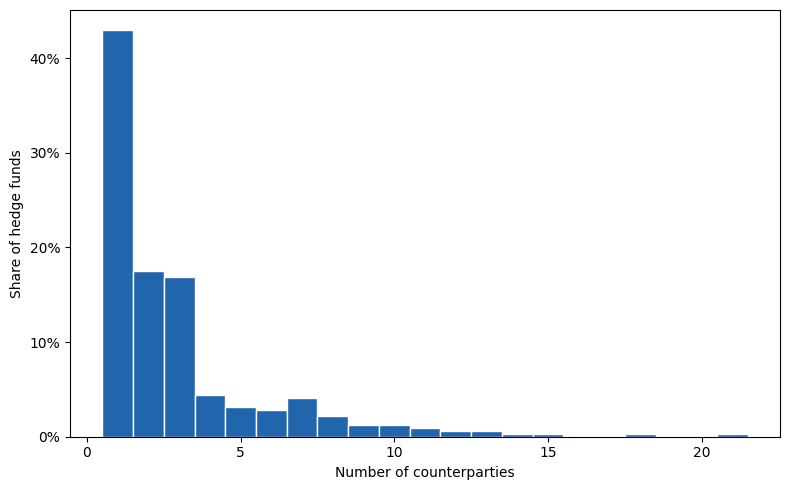

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(cp_per_fund['n_counterparties'], bins=range(1, cp_per_fund['n_counterparties'].max() + 2),
        edgecolor='white', color='#2166ac', align='left',
        weights=[1 / len(cp_per_fund)] * len(cp_per_fund))
ax.set_xlabel('Number of counterparties')
ax.set_ylabel('Share of hedge funds')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()